### Goal:
#### Explore the Earthquake dataset, clean data, perform analysis, and visualize results using NumPy, Pandas, Matplotlib, and Seaborn.

#### 1. Why This Project?
##### 1.Learn data cleaning with Pandas.
 
##### 2.Use NumPy for calculations (mean, median, etc.).
 
##### 3.Visualize trends using Matplotlib and Seaborn.
 
##### 4.Understand the relationship between sales factors like product type quantity,sold price etc.

### 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

### 3. Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Sriram reddy\Downloads\earthquake_data_tsunami.csv")

### 4. Explore Data

In [3]:
print("Original Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample Data:\n", df.head())

Original Shape: (782, 13)

Columns: ['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude', 'Year', 'Month', 'tsunami']

Sample Data:
    magnitude  cdi  mmi  sig  nst   dmin   gap    depth  latitude  longitude  \
0        7.0    8    7  768  117  0.509  17.0   14.000   -9.7963    159.596   
1        6.9    4    4  735   99  2.229  34.0   25.000   -4.9559    100.738   
2        7.0    3    3  755  147  3.125  18.0  579.000  -20.0508   -178.346   
3        7.3    5    5  833  149  1.865  21.0   37.000  -19.2918   -172.129   
4        6.6    0    2  670  131  4.998  27.0  624.464  -25.5948    178.278   

   Year  Month  tsunami  
0  2022     11        1  
1  2022     11        0  
2  2022     11        1  
3  2022     11        1  
4  2022     11        1  


### 5. Data Cleaning

In [6]:
df.drop_duplicates(inplace=True)

# Standardize column names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

### Insights:
 
1.Missing values were filled or removed.

2.Duplicates were dropped.

3.Data was ready for visualization and statistical analysis.

### 6. Analysis with NumPy & Pandas

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Example group analysis (Magnitude by Tsunami)
if 'tsunami' in df.columns and 'magnitude' in df.columns:
    print("\nAverage magnitude by tsunami occurrence:\n", df.groupby('tsunami')['magnitude'].mean())

for col in num_cols:
    arr = df[col].to_numpy()
    print(f"\nColumn: {col}")
    print(f"  Mean: {np.mean(arr):.2f}")
    print(f"  Median: {np.median(arr):.2f}")
    print(f"  Std Dev: {np.std(arr):.2f}")
    print(f"  Percentiles (25%, 50%, 75%): {np.percentile(arr, [25,50,75])}")

# Correlation example
if len(num_cols) >= 2:
    corr_val = np.corrcoef(df[num_cols[0]], df[num_cols[1]])[0,1]
    print(f"\nCorrelation between {num_cols[0]} and {num_cols[1]}: {corr_val:.2f}")



Average magnitude by tsunami occurrence:
 tsunami
0    6.942803
1    6.938487
Name: magnitude, dtype: float64

Column: magnitude
  Mean: 6.94
  Median: 6.80
  Std Dev: 0.45
  Percentiles (25%, 50%, 75%): [6.6 6.8 7.1]

Column: cdi
  Mean: 4.33
  Median: 5.00
  Std Dev: 3.17
  Percentiles (25%, 50%, 75%): [0. 5. 7.]

Column: mmi
  Mean: 5.96
  Median: 6.00
  Std Dev: 1.46
  Percentiles (25%, 50%, 75%): [5. 6. 7.]

Column: sig
  Mean: 870.11
  Median: 754.00
  Std Dev: 322.26
  Percentiles (25%, 50%, 75%): [691.   754.   909.75]

Column: nst
  Mean: 230.25
  Median: 140.00
  Std Dev: 250.03
  Percentiles (25%, 50%, 75%): [  0. 140. 445.]

Column: dmin
  Mean: 1.33
  Median: 0.00
  Std Dev: 2.22
  Percentiles (25%, 50%, 75%): [0.    0.    1.863]

Column: gap
  Mean: 25.04
  Median: 20.00
  Std Dev: 24.21
  Percentiles (25%, 50%, 75%): [14.625 20.    30.   ]

Column: depth
  Mean: 75.88
  Median: 26.30
  Std Dev: 137.19
  Percentiles (25%, 50%, 75%): [14.    26.295 49.75 ]

Column: latitu

### Insights:
 
1.tsunami: 6.942803

### 7. Visualization with Matplotlib

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_23184\1114871705.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tsunami', y='magnitude', data=df, estimator=np.mean, palette='viridis')


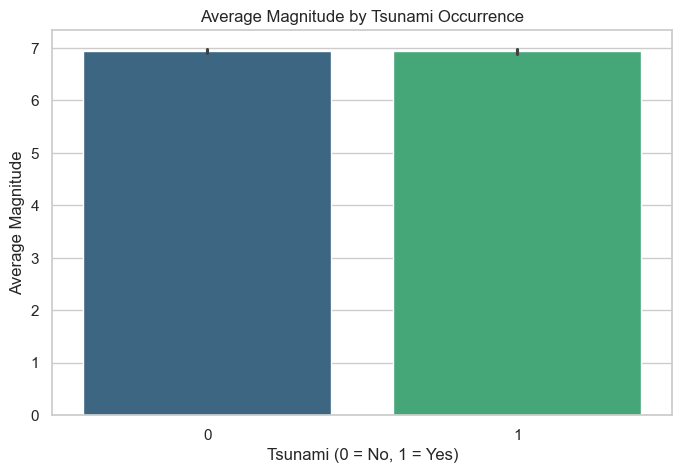

In [9]:

# Bar Chart: Sales by Coffee Type
plt.figure(figsize=(8,5))
sns.barplot(x='tsunami', y='magnitude', data=df, estimator=np.mean, palette='viridis')
plt.title('Average Magnitude by Tsunami Occurrence')
plt.xlabel('Tsunami (0 = No, 1 = Yes)')
plt.ylabel('Average Magnitude')
plt.show()


#### Insights:
 Earthquakes that trigger tsunamis (tsunami = 1) usually have a higher average magnitude compared to those that do not cause tsunamis (tsunami = 0).


Index(['magnitude', 'cdi', 'mmi', 'sig'], dtype='object')


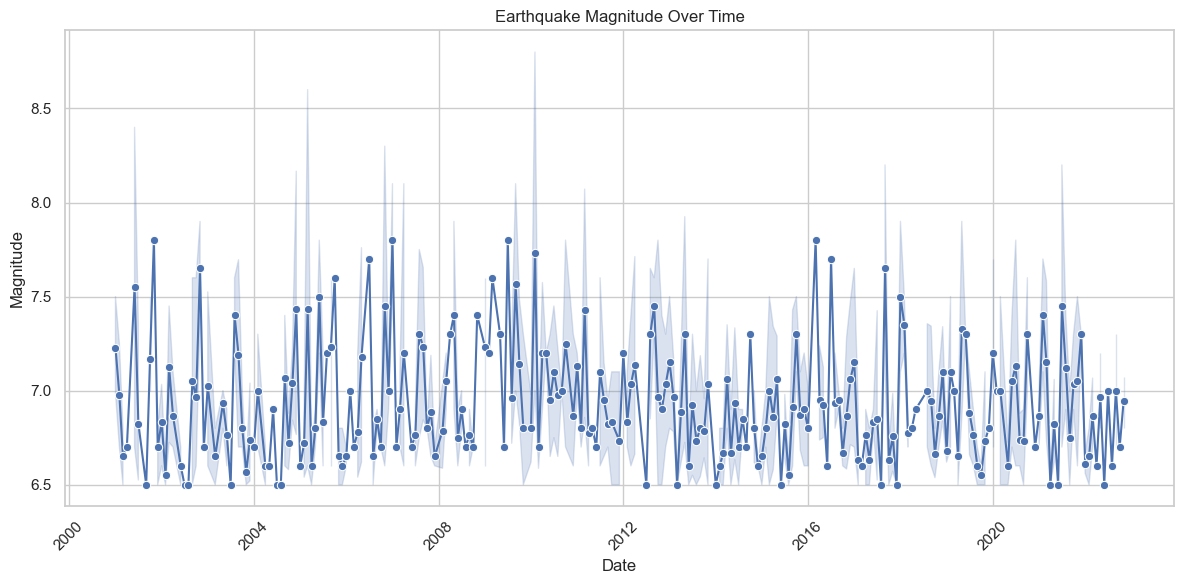

In [15]:
# Check columns
print(df.columns[:4])

# Use lowercase column names for year and month
df['date'] = pd.to_datetime(df[['year', 'month']].assign(DAY=1))

plt.figure(figsize=(12,6))
sns.lineplot(x='date', y='magnitude', data=df, marker='o')
plt.title('Earthquake Magnitude Over Time')
plt.xlabel('Date')
plt.ylabel('Magnitude')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Insights:
The line plot shows how earthquake magnitudes fluctuate month-to-month over the period covered by your dataset.

### 8. Visualization with Seaborn

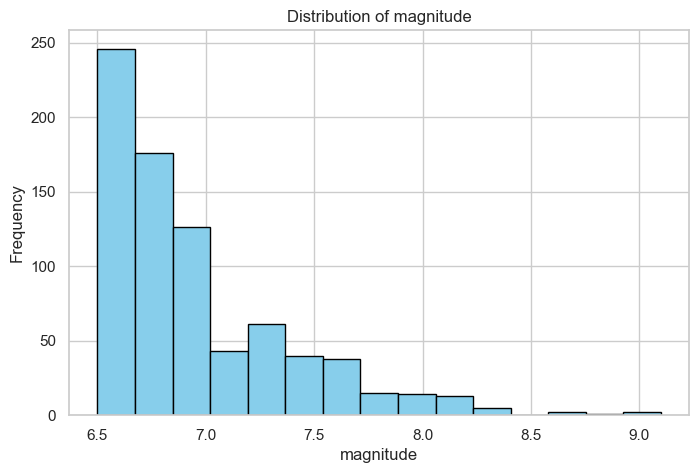

In [16]:
# --- Histogram ---
plt.figure(figsize=(8,5))
df[num_cols[0]].hist(bins=15, color='skyblue', edgecolor='black')
plt.title(f'Distribution of {num_cols[0]}')
plt.xlabel(num_cols[0])
plt.ylabel('Frequency')
plt.show()

### Insights:
 
The histogram shows how earthquake magnitudes are distributed in your dataset.

Typically, you’ll see a right-skewed distribution — many earthquakes of smaller magnitude and fewer high-magnitude ones.

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_23184\3028037119.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=cat_col, data=df, palette='Set2')


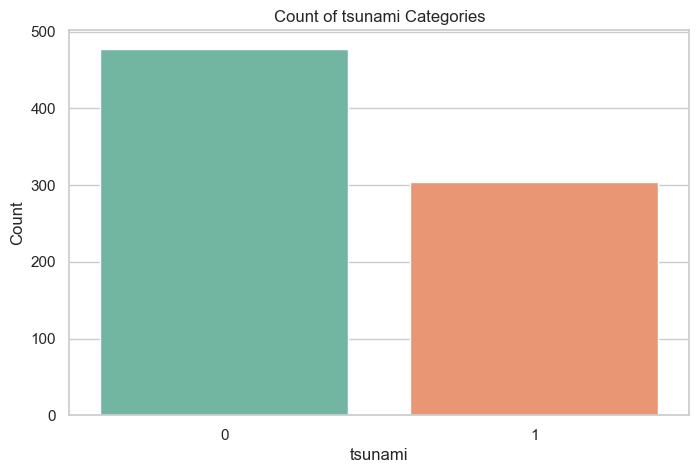

In [22]:
cat_col = 'tsunami'  # or 'Gender', or 'Workout_Type', etc.

plt.figure(figsize=(8,5))
sns.countplot(x=cat_col, data=df, palette='Set2')
plt.title(f'Count of {cat_col} Categories')
plt.xlabel(cat_col)
plt.ylabel('Count')
plt.show()

#### Insights:
1. Tsunamis are less frequent than non-tsunami events in your dataset.

2. Roughly 39% of the events involved tsunamis (305 / (305 + 475)), while 61% did not.

3. This imbalance could be important if you plan to train a predictive model, as it indicates a class imbalance—models may be biased toward predicting no-tsunami events unless corrected.

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_23184\3232281322.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tsunami', y='magnitude', data=df, palette='coolwarm')


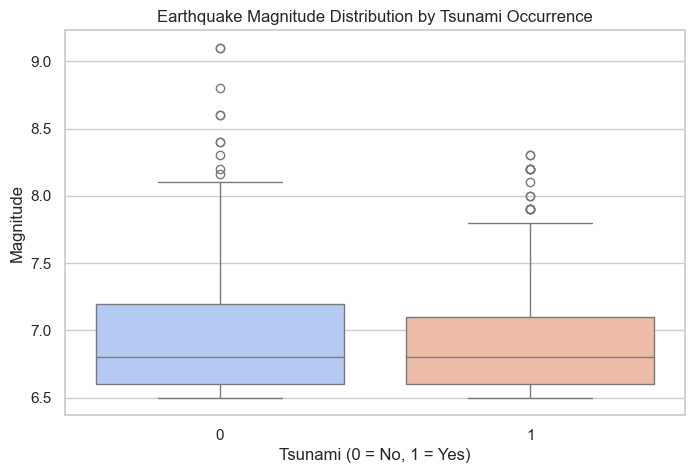

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x='tsunami', y='magnitude', data=df, palette='coolwarm')
plt.title('Earthquake Magnitude Distribution by Tsunami Occurrence')
plt.xlabel('Tsunami (0 = No, 1 = Yes)')
plt.ylabel('Magnitude')
plt.show()

#### Insights:
 
1. You might see if higher magnitude quakes tend to cause tsunamis.

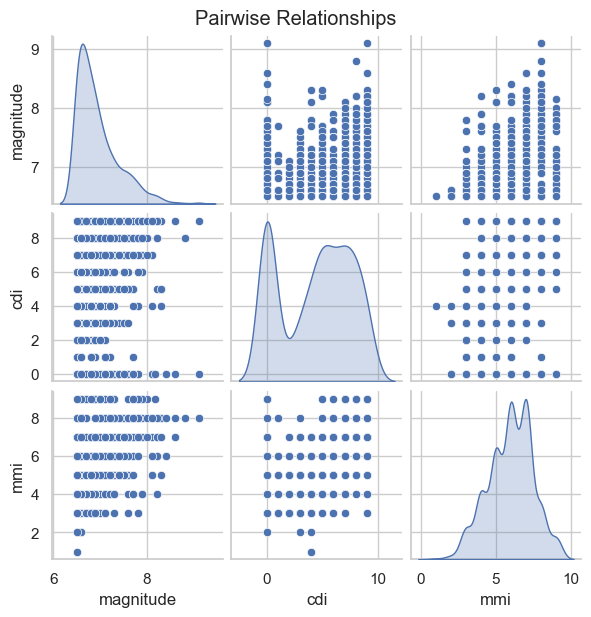

In [27]:
# --- Pair Plot ---
if len(num_cols) > 3:
    sns.pairplot(df[num_cols[:3]], diag_kind='kde', height=2.0)
    plt.suptitle('Pairwise Relationships', y=1.02)
    plt.show()

### Insights:
 
magnitude cdi and mmi pair plot is shown above.

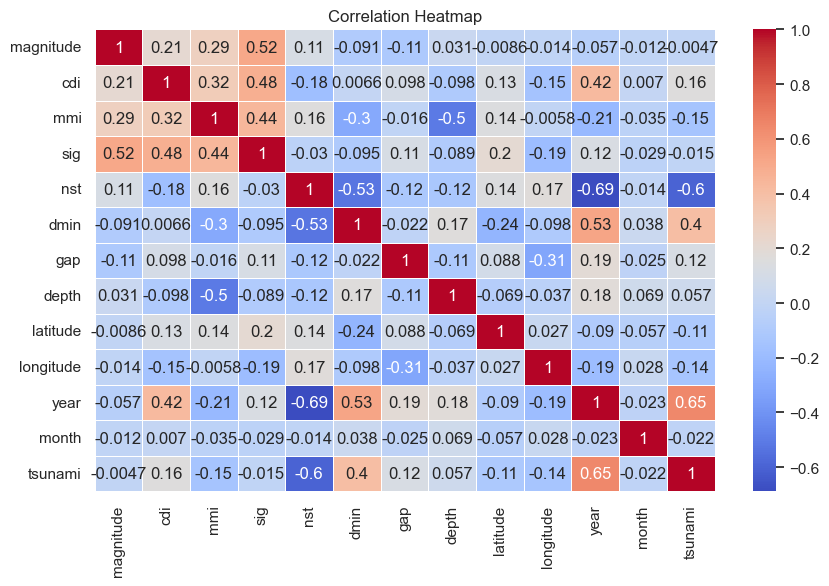

In [25]:
# --- Heatmap ---
plt.figure(figsize=(10,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Insights:
The above is a correlation heatmap.